# Decision Boundary: XOR Problem — Fine-tuning TabPFN v3

Compares vanilla TabPFN v3 vs fine-tuned TabPFN v3 on a 2D XOR classification task.

**Fine-tuning approach (using custom `TabPFNFinetuner` from `finetuning_engine`):**
1. Each epoch randomly splits training data into a context (support) set and a query set.
2. The model sees all rows as features, only context labels — same meta-learning setup as pre-training.
3. CrossEntropyLoss is computed on query predictions.
4. Gradients update the underlying TabPFN transformer weights.

**`TabPFNFinetuner` key parameters:**
| Parameter | Role |
|---|---|
| `epochs` | Number of fine-tuning epochs |
| `learning_rate` | AdamW LR (small values, e.g. 1e-5 to 1e-4, recommended) |
| `query_ratio` | Fraction of training samples used as query set per epoch |
| `patience` | Early-stopping patience (epochs without val improvement) |
| `grad_clip` | Max gradient norm for clipping (0 = disabled) |
| `freeze_feature_attn` | Freeze feature-attention sub-modules |
| `freeze_row_attn` | Freeze row-attention sub-modules |
| `freeze_decoder` | Freeze the output decoder head |
| `warmup_proportion` | Fraction of steps used for LR warmup |

In [8]:
import sys
sys.path.insert(0, "..")

import warnings
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

## 1. Generate XOR dataset

Features: 10 | Train: 240 | Val: 60 | Test: 100


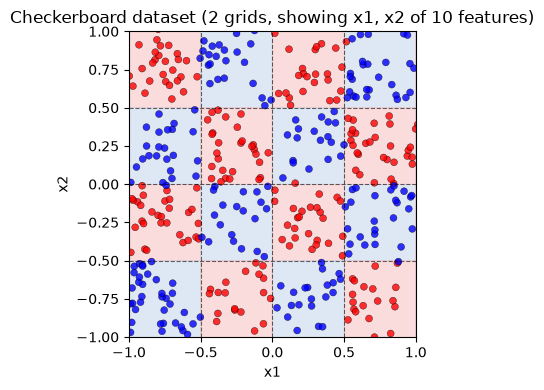

In [9]:
N_FEATURES = 10  # total number of features (checker label uses first 2; rest are noise)

def make_xor(n_samples: int = 400, noise: float = 0.01, n_features: int = N_FEATURES, random_state: int = 42, gap: float = 0.01):
    """Checkerboard classification with 2 grids per axis (4x4 tiles).
    First 2 features carry the signal; remaining features are Gaussian noise.
    Label = (floor(x1 * 2) mod 2) XOR (floor(x2 * 2) mod 2).
    gap: width of empty margin around each tile boundary (in data units)."""
    rng = np.random.default_rng(random_state)

    # Oversample then reject points too close to any tile boundary
    boundaries = np.array([-0.5, 0.0, 0.5])
    half_gap = gap / 2
    oversample_factor = int(np.ceil(1 / (1 - gap * len(boundaries)) ** 2)) + 2

    X_signal = rng.uniform(-1, 1, size=(n_samples * oversample_factor, 2))
    dist_x = np.min(np.abs(X_signal[:, 0:1] - boundaries), axis=1)
    dist_y = np.min(np.abs(X_signal[:, 1:2] - boundaries), axis=1)
    keep = (dist_x >= half_gap) & (dist_y >= half_gap)
    X_signal = X_signal[keep][:n_samples]

    # 2-period checkerboard: divide each axis into 4 equal bands
    grid_x = np.floor(X_signal[:, 0] * 2).astype(int) % 2
    grid_y = np.floor(X_signal[:, 1] * 2).astype(int) % 2
    y = (grid_x ^ grid_y).astype(int)
    X_signal += rng.normal(0, noise, size=X_signal.shape)

    if n_features > 2:
        X_noise = rng.normal(0, 0.5, size=(len(X_signal), n_features - 2))
        X = np.concatenate([X_signal, X_noise], axis=1)
    else:
        X = X_signal

    return X.astype(np.float32), y


X, y = make_xor()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Features: {X.shape[1]} | Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test)}")

fig, ax = plt.subplots(figsize=(4, 4))

# Shade true decision regions
res = 300
xx, yy = np.meshgrid(np.linspace(-1, 1, res), np.linspace(-1, 1, res))
zz = ((np.floor(xx * 2).astype(int) % 2) ^ (np.floor(yy * 2).astype(int) % 2)).astype(float)
ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["#aec6e8", "#f5a8a8"], alpha=0.4)

# True boundary lines
for v in [-0.5, 0.0, 0.5]:
    ax.axvline(v, color="k", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.axhline(v, color="k", linewidth=0.8, linestyle="--", alpha=0.6)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", linewidths=0.3, s=25, alpha=0.8)
ax.set_title(f"Checkerboard dataset (2 grids, showing x1, x2 of {X.shape[1]} features)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

## 2. Helper: plot decision boundary

In [10]:
def plot_decision_boundary(clf, X, y, ax, title, resolution=30):
    """Fill a 2D decision boundary for a binary classifier.
    Sweeps over the first two features; all remaining features are fixed at 0."""
    x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    grid_2d = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    # Pad extra features with zeros so the classifier sees the right shape
    n_features = X.shape[1]
    if n_features > 2:
        padding = np.zeros((len(grid_2d), n_features - 2), dtype=np.float32)
        grid = np.concatenate([grid_2d, padding], axis=1)
    else:
        grid = grid_2d

    proba = clf.predict_proba(grid)[:, 1]  # P(class = 1)
    Z = proba.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=50, cmap=plt.cm.RdBu_r, alpha=0.75, vmin=0, vmax=1)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.2)

    colors = np.where(y == 1, "#d62728", "#1f77b4")
    ax.scatter(X[:, 0], X[:, 1], c=colors, edgecolors="w", linewidths=0.4, s=30, zorder=3)

    acc = (clf.predict(X) == y).mean()
    ax.set_title(f"{title}\nacc={acc:.3f}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

## 3. Vanilla TabPFN v3 (no fine-tuning)

In [11]:
from tabpfn import TabPFNClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

clf_vanilla = TabPFNClassifier(
    n_estimators=8,
    device=device,
    random_state=42,
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_vanilla.fit(X_tr, y_tr)

print(f"Vanilla TabPFN v3 test acc: {(clf_vanilla.predict(X_test) == y_test).mean():.4f}")

Using device: cpu
Vanilla TabPFN v3 test acc: 0.5100


## 4. Fine-tuned TabPFN v3

Uses `TabPFNFinetuner` from `finetuning_engine` — a custom meta-learning fine-tuning loop
that directly backpropagates through TabPFN's transformer weights.

Training history (loss + val accuracy) is stored in `clf_finetuned.history` and can be
plotted with `clf_finetuned.plot_history()`.

In [12]:
from finetuning_engine import TabPFNFinetuner

clf_finetuned = TabPFNFinetuner(
    epochs=50,
    learning_rate=1e-4,
    query_ratio=0.3,
    grad_clip=1.0,
    patience=20,
    warmup_proportion=0.1,
    freeze_feature_attn=False,
    freeze_row_attn=False,
    freeze_decoder=False,
    device=device,
    random_state=42,
    verbose=True,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_finetuned.fit(X_tr, y_tr, X_val, y_val)

  [finetune] baseline val_acc = 0.5667 | val_loss = 0.6969
  [finetune] epoch   1/50 | train_loss=0.7045 | val_loss=0.6969 | val_acc=0.5667 | time=1.1s
  [finetune] epoch   2/50 | train_loss=0.7052 | val_loss=0.6947 | val_acc=0.5667 | time=1.1s
  [finetune] epoch   3/50 | train_loss=0.7031 | val_loss=0.6917 | val_acc=0.5500 | time=1.1s
  [finetune] epoch   4/50 | train_loss=0.6773 | val_loss=1.1255 | val_acc=0.5667 | time=1.0s
  [finetune] epoch   5/50 | train_loss=0.9666 | val_loss=0.7068 | val_acc=0.5667 | time=2.0s
  [finetune] epoch   6/50 | train_loss=0.6714 | val_loss=1.2057 | val_acc=0.4833 | time=2.2s
  [finetune] epoch   7/50 | train_loss=0.9330 | val_loss=1.0947 | val_acc=0.5000 | time=2.2s
  [finetune] epoch   8/50 | train_loss=1.0699 | val_loss=0.7372 | val_acc=0.5000 | time=2.1s
  [finetune] epoch   9/50 | train_loss=0.7041 | val_loss=0.7135 | val_acc=0.5167 | time=2.2s
  [finetune] epoch  10/50 | train_loss=0.7602 | val_loss=0.7240 | val_acc=0.5333 | time=2.1s
  [finetune

## 5. Training history

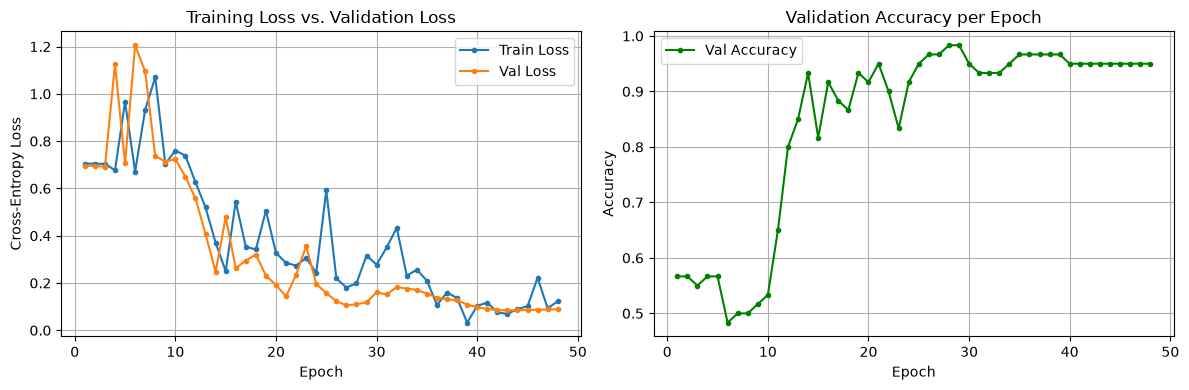

In [13]:
clf_finetuned.plot_history()

In [14]:
print(f"Vanilla     TabPFN v3 test acc: {(clf_vanilla.predict(X_test) == y_test).mean():.4f}")
print(f"Fine-tuned  TabPFN v3 test acc: {(clf_finetuned.predict(X_test) == y_test).mean():.4f}")

Vanilla     TabPFN v3 test acc: 0.5100
Fine-tuned  TabPFN v3 test acc: 0.6500


## 6. Side-by-side decision boundary comparison

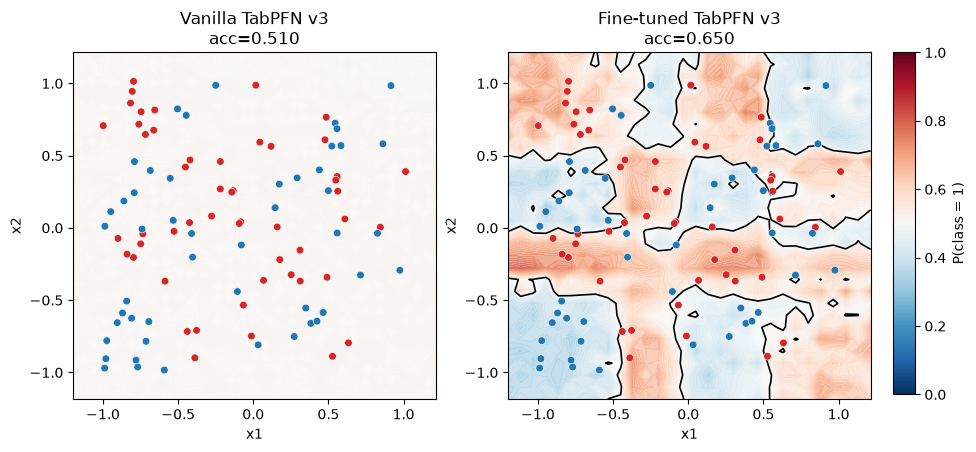

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

plot_decision_boundary(clf_vanilla,   X_test, y_test, axes[0], "Vanilla TabPFN v3")
plot_decision_boundary(clf_finetuned, X_test, y_test, axes[1], "Fine-tuned TabPFN v3")

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=mcolors.Normalize(vmin=0, vmax=1))
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.12, 0.02, 0.76])
fig.colorbar(sm, cax=cbar_ax, label="P(class = 1)")

plt.show()